In [2]:
%load_ext autoreload
%autoreload 2

In [28]:
from utils.llm_api.client import GPT4AllClient, GPT4AllMessage
import pandas as pd
from utils.pipeline import run_pipeline
import os, io
from utils.llm_api.client import HuggingFaceLLMClient
from utils.llm_api.query import QueryProvider, QueryType
import json
import logging
import re
from utils.pipeline import extract_python_code, extract_json

In [4]:
llm_client = GPT4AllClient()

In [5]:
available_models = llm_client.get_available_models()
available_models

['Llama 3.2 3B Instruct',
 'Llama 3.2 1B Instruct',
 'Llama 3.1 8B Instruct 128k',
 'nomic-ai/nomic-embed-text-v1.5-GGUF']

In [6]:
def convert_potential_numerical(data: pd.DataFrame, threshold: float = 0.1) -> pd.DataFrame:
    numeric_columns = []
    for col in data.columns:
        try:
            # Try converting the column to numeric; check for NaNs
            temp = pd.to_numeric(data[col], errors='coerce')
            if temp.isna().sum() < threshold * len(data):  # Check if there are no NaN values
                data[col] = temp
        except:
            pass  # Ignore errors for non-convertible columns

    # Convert only those columns to numeric
    data[numeric_columns] = data[numeric_columns].apply(pd.to_numeric)
    
    return data

In [7]:
data = pd.read_csv("./data/LUCAS-SOIL-2018.csv")
data = convert_potential_numerical(data)
buffer = io.StringIO()
data.info(buf=buffer)
data_description = buffer.getvalue()

objective = "Plot the average ‘OC’ for each land type (LC0_Desc). save it as a png."
with open('./function_headers/all.txt') as f:
    functions = f.readlines()
    functions = "\n".join(functions)

with open('./function_headers/transform.txt') as f:
    transform_functions = f.readlines()
    transform_functions = "\n".join(functions)
    
with open('./function_headers/visualize.txt') as f:
    visualize_functions = f.readlines()
    visualize_functions = "\n".join(functions)

In [29]:
MODEL_NAME_INSTRUCTOR = 'Llama 3.1 8B Instruct 128k'
MODEL_NAME_CODER = 'Llama 3.1 8B Instruct 128k'

client_instructor = GPT4AllClient(model_name=MODEL_NAME_INSTRUCTOR)
client_coder = GPT4AllClient(model_name=MODEL_NAME_CODER)

In [30]:
initial_query = QueryProvider.get_query(query_type=QueryType.INITIAL, 
                                        objective=objective, 
                                        data_description=data_description)
logging.log(logging.INFO, "Running initial query")
response = client_instructor.query(initial_query)

logging.log(logging.INFO, f"Initial query finished successfully, response: {response}")

logging.log(logging.INFO, "Started parsing response")
try:
    parsed_response = extract_json(response)
    transform_instructions = parsed_response["transform"]
    visualize_instructions = parsed_response["visualize"]
    intermediate_data_description = parsed_response["column_definitions"]
except Exception as e:
    raise ValueError("Parsed response is not in json format or does not contain transform, visualize, or column_definitions keys.")
logging.log(logging.INFO, "Parsing successful")

2025-01-19 22:41:26,027 - Running initial query
2025-01-19 22:41:40,838 - Initial query finished successfully, response: Here is the solution in JSON format:

```json
{
  "transform": {
    "step1": "Read the CSV file './data/LUCAS-SOIL-2018.csv' into a pandas DataFrame.",
    "column_selection": [
      {"name": "OC", "type": "float64"},
      {"name": "LC0_Desc", "type": "object"}
    ],
    "groupby_column": ["LC0_Desc"],
    "agg_operation": "mean"
  },
  "visualize": {
    "plot_type": "bar plot",
    "x_axis_label": "Land type (LC0_Desc)",
    "y_axis_label": "Average OC value",
    "save_as": "average_OC_per_landtype.png"
  },
  "column_definitions": [
    {"name": "Mean_OC", "type": "float64"}
  ]
}
```
2025-01-19 22:41:40,839 - Started parsing response
2025-01-19 22:41:40,840 - Parsing successful


In [31]:
logging.log(logging.INFO, "Running transform query")
transform_query = QueryProvider.get_query(query_type=QueryType.TRANSFORM,
                                        objective=transform_instructions,
                                        data_description=data_description,
                                        functions=transform_functions,
                                        intermediate_data_description=intermediate_data_description)
transform_response = client_coder.query(transform_query)

logging.log(logging.INFO, f"Transform query finished successfully, response: {extract_python_code(transform_response)}")

2025-01-19 22:42:36,570 - Running transform query
2025-01-19 22:42:54,204 - Transform query finished successfully, response: import pandas as pd

def transform(data):
    # Group by 'LC0_Desc' and calculate mean of 'OC'
    grouped = data.groupby('LC0_Desc')['OC'].mean().reset_index()
    
    # Rename the column to match expected output format
    final_dataframe = grouped.rename(columns={'OC': 'Mean_OC'})
    
    return final_dataframe

# Call the function with your dataframe as argument
final_dataframe = transform(data)


In [40]:
def transform(data):
    # Group by 'LC0_Desc' and calculate mean of 'OC'
    grouped = data.groupby('LC0_Desc')['OC'].mean().reset_index()
    
    # Rename the column to match expected output format
    final_dataframe = grouped.rename(columns={'OC': 'Mean_OC'})
    
    return final_dataframe

# Call the function with your dataframe as argument
final_dataframe = transform(data)
final_dataframe

,LC0_Desc,Mean_OC
0,Artificial land,36.860000
1,Bareland,17.329794
2,Cropland,18.274002
3,Grassland,40.153766
4,Shrubland,55.042249
5,Water,15.320000
6,Wetlands,318.072500
7,Woodland,88.869290


In [34]:
buffer = io.StringIO()
final_dataframe.info(buf=buffer)
intermediate_data_description = buffer.getvalue()

In [38]:
logging.log(logging.INFO, "Running visualize query")

visualize_query = QueryProvider.get_query(query_type=QueryType.VISUALIZE,
                                            objective=visualize_instructions,
                                            intermediate_data_description=intermediate_data_description,
                                            functions=visualize_functions
                                            )

visualize_response = client_coder.query(visualize_query)
logging.log(logging.INFO, f"Visualize query finished successfully, response: {extract_python_code(visualize_response)}")

2025-01-19 22:52:53,869 - Running visualize query
2025-01-19 22:53:05,772 - Visualize query finished successfully, response: import pandas as pd
import matplotlib.pyplot as plt

final_dataframe = pd.read_csv('./data/LUCAS-SOIL-2018.csv')

# Group the data by LC0_Desc and calculate the mean of Mean_OC for each group
mean_oc_per_landtype = final_dataframe.groupby('LC0_Desc')['Mean_OC'].mean().reset_index()

plt.figure(figsize=(10,6))
plt.bar(mean_oc_per_landtype['LC0_Desc'], mean_oc_per_landtype['Mean_OC'])
plt.xlabel('Land type (LC0_Desc)')
plt.ylabel('Average OC value')
plt.title('Bar plot of Average OC per Land Type')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('average_OC_per_landtype.png')


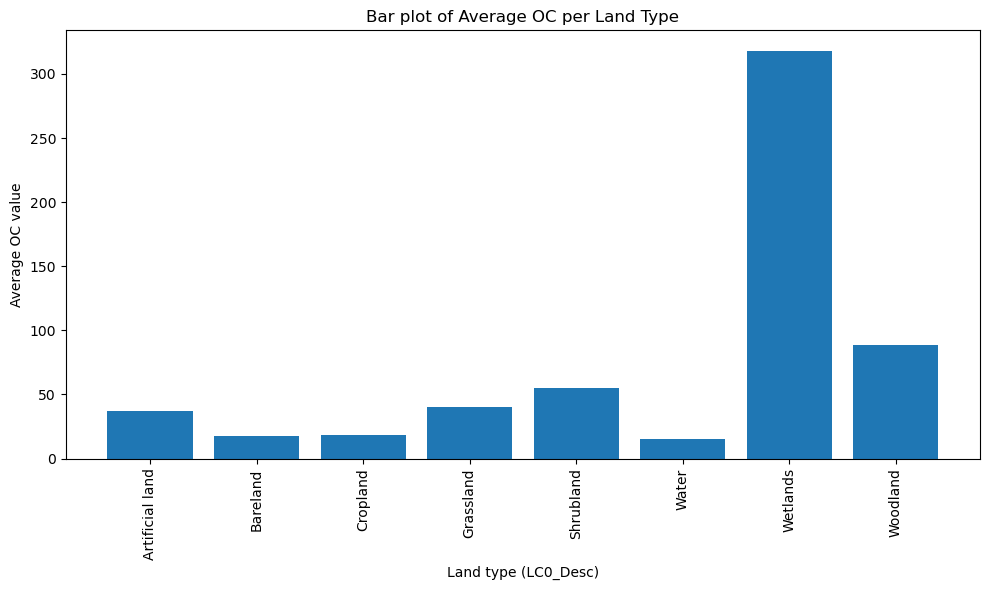

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

mean_oc_per_landtype = final_dataframe.groupby('LC0_Desc')['Mean_OC'].mean().reset_index()

plt.figure(figsize=(10,6))
plt.bar(mean_oc_per_landtype['LC0_Desc'], mean_oc_per_landtype['Mean_OC'])
plt.xlabel('Land type (LC0_Desc)')
plt.ylabel('Average OC value')
plt.title('Bar plot of Average OC per Land Type')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('average_OC_per_landtype.png')